# EDA: Survival Patterns by Breast Cancer Subtype

This notebook is my initial look at the METABRIC data — mostly focused on how survival differs across molecular subtypes and what the receptor status breakdown looks like. I also wanted to get a feel for the age distribution and how much data we're actually working with after dropping missing survival info.

The Kaplan-Meier curves were the main thing I wanted to see early on since our first problem statement is specifically about subtype differences. I also added a section on the integrative clusters (IntClust) since those are the main finding from the original Curtis et al. 2012 paper that produced this dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test 
# To install lifelines use ```!pip install lifelines --no-cache-dir```

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

In [3]:
df = pd.read_csv('../data/raw_data/brca_metabric_clinical_data.tsv', sep='\t')
print(f'Loaded {df.shape[0]} patients, {df.shape[1]} columns')
df.head(3)

Loaded 2509 patients, 39 columns


,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,...,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,...,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,...,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,...,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease


## 1. Quick data check

Before anything else, just checking the survival columns and subtype column for missing values. We already know from the README that we lose ~500 patients when filtering to those with survival data.

In [ ]:
survival_cols = ['OS_MONTHS', 'OS_STATUS', 'RFS_MONTHS', 'RFS_STATUS', 'CLAUDIN_SUBTYPE']
print('Missing values in key columns:')
print(df[survival_cols].isnull().sum())
print(f'\nCLAUDIN_SUBTYPE values: {df["Pam50 + Claudin-low subtype"].unique()}')

Missing values in key columns:


KeyError: "None of [Index(['OS_MONTHS', 'OS_STATUS', 'RFS_MONTHS', 'RFS_STATUS',\n       'CLAUDIN_SUBTYPE'],\n      dtype='object')] are in the [columns]"

In [ ]:
# drop rows missing OS data or subtype
df_os = df.dropna(subset=['OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE']).copy()

# encode OS_STATUS as binary (1 = deceased)
df_os['deceased'] = df_os['OS_STATUS'].str.upper().str.contains('DECEASED|DEAD|1').astype(int)

print(f'Working with {len(df_os)} patients after dropping missing OS/subtype')
print(f'Deceased: {df_os["deceased"].sum()} ({df_os["deceased"].mean()*100:.1f}%)')

## 2. Subtype distribution

CLAUDIN_SUBTYPE gives us the PAM50-like molecular subtypes. Triple-negative corresponds to the Basal-like group here.

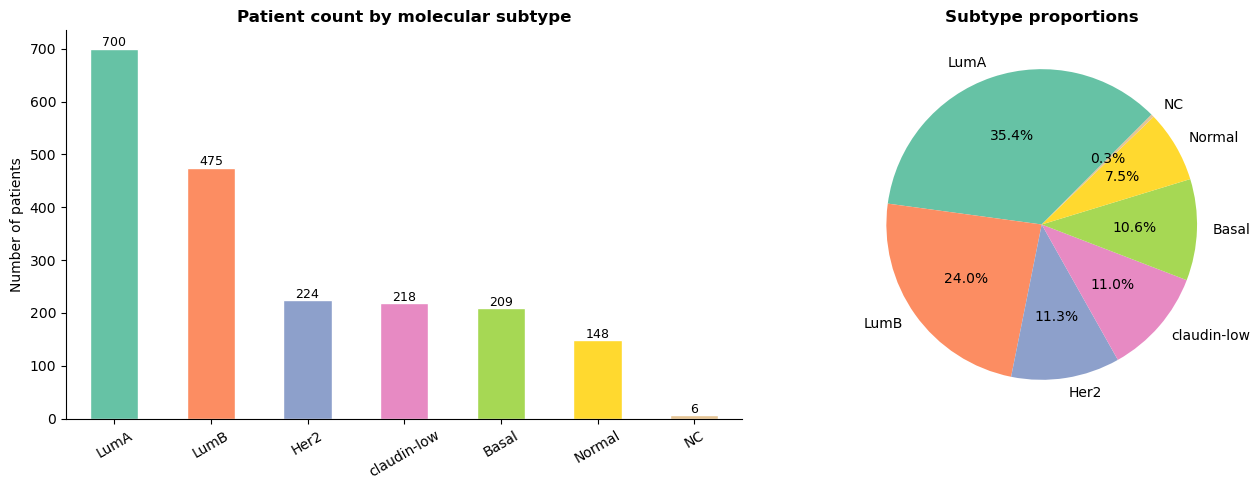

Luminal A dominates as expected — Basal (TNBC proxy) is ~11%


In [ ]:
subtype_counts = df['Pam50 + Claudin-low subtype'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart to show the counts of claudin subtypes in the data. 
subtype_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2', len(subtype_counts)), edgecolor='white')
axes[0].set_title('Patient count by molecular subtype', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of patients')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(subtype_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# pie chart
axes[1].pie(subtype_counts.values, labels=subtype_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(subtype_counts)), startangle=45)
axes[1].set_title('Subtype proportions', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/claudin_subtype_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Luminal A dominates as expected & Basal (TNBC proxy) is ~11%\n')

## 3. Kaplan-Meier survival curves by subtype

This is the main thing I wanted to see. The KM curves give us an intuitive view of survival differences before we do any modeling. The log-rank test tells us whether the differences are statistically significant.

In [ ]:
subtypes = df_os['CLAUDIN_SUBTYPE'].unique()
colors = sns.color_palette('Set2', len(subtypes))

fig, ax = plt.subplots(figsize=(11, 7))
kmf = KaplanMeierFitter()

for i, subtype in enumerate(subtypes):
    mask = df_os['CLAUDIN_SUBTYPE'] == subtype
    kmf.fit(
        durations=df_os.loc[mask, 'OS_MONTHS'],
        event_observed=df_os.loc[mask, 'deceased'],
        label=f'{subtype} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=False, color=colors[i])

ax.set_title('Overall Survival by Molecular Subtype (METABRIC)', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('km_curves_by_subtype.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# log-rank test across all subtypes
results = multivariate_logrank_test(
    df_os['OS_MONTHS'],
    df_os['CLAUDIN_SUBTYPE'],
    df_os['deceased']
)
print(f'Multivariate log-rank test p-value: {results.p_value:.2e}')
print('Survival differences across subtypes are', 'significant (p < 0.05)' if results.p_value < 0.05 else 'not significant')

## 4. Basal (TNBC proxy) vs. everything else

Since problem statement #1 specifically asks about triple-negative patients, I wanted to isolate Basal vs. the rest and do a direct pairwise comparison.

In [ ]:
df_os['is_basal'] = (df_os['CLAUDIN_SUBTYPE'] == 'Basal').astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
kmf = KaplanMeierFitter()

for group, label, color in [(1, 'Basal / TNBC-like', '#e74c3c'), (0, 'All other subtypes', '#2ecc71')]:
    mask = df_os['is_basal'] == group
    kmf.fit(
        durations=df_os.loc[mask, 'OS_MONTHS'],
        event_observed=df_os.loc[mask, 'deceased'],
        label=f'{label} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

# pairwise log-rank
lr = logrank_test(
    df_os.loc[df_os['is_basal']==1, 'OS_MONTHS'],
    df_os.loc[df_os['is_basal']==0, 'OS_MONTHS'],
    event_observed_A=df_os.loc[df_os['is_basal']==1, 'deceased'],
    event_observed_B=df_os.loc[df_os['is_basal']==0, 'deceased']
)

ax.set_title(f'Basal vs. Non-Basal Overall Survival\n(log-rank p = {lr.p_value:.2e})', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('km_basal_vs_rest.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Receptor status breakdown

ER/PR/HER2 status is the clinical way subtypes are defined, so good to see the counts and how they map onto the molecular subtypes.

In [ ]:
receptor_cols = ['ER_STATUS', 'PR_STATUS', 'HER2_STATUS']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, receptor_cols):
    counts = df[col].value_counts(dropna=False)
    colors_bar = ['#e74c3c' if 'Pos' in str(v) else '#95a5a6' if pd.isna(v) else '#3498db' for v in counts.index]
    counts.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(col.replace('_', ' '), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(counts):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.suptitle('Receptor Status Distribution (all 2509 patients)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('receptor_status.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# heatmap: subtype vs. receptor status (% positive)
for col in receptor_cols:
    df_os[col + '_bin'] = (df_os[col].str.upper() == 'POSITIVE').astype(float)

receptor_by_subtype = df_os.groupby('CLAUDIN_SUBTYPE')[[c + '_bin' for c in receptor_cols]].mean() * 100
receptor_by_subtype.columns = ['ER+%', 'PR+%', 'HER2+%']

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(receptor_by_subtype, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': '% Positive'})
ax.set_title('Receptor Positivity Rate by Molecular Subtype (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('receptor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Basal subtype shows near-zero ER/PR/HER2 positivity — consistent with TNBC biology')

## 6. Age at diagnosis

Just wanted to see the age distribution and whether it differs by subtype — younger age at diagnosis is a known feature of TNBC.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall distribution
axes[0].hist(df['AGE_AT_DIAGNOSIS'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['AGE_AT_DIAGNOSIS'].median(), color='red', linestyle='--', label=f'Median: {df["AGE_AT_DIAGNOSIS"].median():.0f}')
axes[0].set_title('Age at Diagnosis (all patients)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# by subtype
subtype_order = df_os.groupby('CLAUDIN_SUBTYPE')['AGE_AT_DIAGNOSIS'].median().sort_values().index
df_os.boxplot(column='AGE_AT_DIAGNOSIS', by='CLAUDIN_SUBTYPE', ax=axes[1],
              order=subtype_order, patch_artist=True)
axes[1].set_title('Age at Diagnosis by Subtype', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Tumor grade and stage by subtype

Important to look at before modeling — if Basal tumors are systematically higher grade, that's a confounder we need to control for (which ties directly into problem statement #1).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, title in zip(axes, ['GRADE', 'TUMOR_STAGE'], ['Tumor Grade', 'Tumor Stage']):
    ct = pd.crosstab(df_os['CLAUDIN_SUBTYPE'], df_os[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='white')
    ax.set_title(f'{title} by Subtype (% of subtype)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title=col, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('grade_stage_by_subtype.png', dpi=150, bbox_inches='tight')
plt.show()
print('Basal tumors skew heavily toward Grade 3 — this will be important to account for in the adjusted analysis')

## 8. Integrative clusters (IntClust) survival

The original Curtis et al. (2012) *Nature* paper — which defined and published this dataset — identified 10 integrative clusters (IntClust 1–10) using joint copy number + gene expression profiling. These clusters are the paper's central contribution. The INTCLUST column in our data maps directly to them.

It's worth comparing survival across IntClusts directly since the paper shows some stark differences: IntClust 2 (ER+ with 11q13/14 amplification) and IntClust 5 (ERBB2-amplified) have the worst outcomes, while IntClust 3, 4, 7, 8 are relatively favorable.

One interesting note from the paper: Basal-like tumors (concentrated in IntClust 10) have poor *early* survival but show a relative flattening after ~5 years compared to some ER+ groups — worth looking for that crossover in the curves.

In [ ]:
df_intclust = df.dropna(subset=['OS_MONTHS', 'OS_STATUS', 'INTCLUST']).copy()
df_intclust['deceased'] = df_intclust['OS_STATUS'].str.upper().str.contains('DECEASED|DEAD|1').astype(int)
df_intclust['INTCLUST'] = df_intclust['INTCLUST'].astype(str)

print(f'IntClust analysis: {len(df_intclust)} patients')
print(df_intclust['INTCLUST'].value_counts().sort_index())

In [ ]:
clusters = sorted(df_intclust['INTCLUST'].unique(), key=lambda x: float(x))
colors_ic = sns.color_palette('tab10', len(clusters))

fig, ax = plt.subplots(figsize=(12, 8))
kmf = KaplanMeierFitter()

for i, clust in enumerate(clusters):
    mask = df_intclust['INTCLUST'] == clust
    kmf.fit(
        durations=df_intclust.loc[mask, 'OS_MONTHS'],
        event_observed=df_intclust.loc[mask, 'deceased'],
        label=f'IntClust {clust} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=False, color=colors_ic[i])

ax.set_title('Overall Survival by Integrative Cluster (Curtis et al. 2012)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (months)')
ax.set_ylabel('Survival probability')
ax.set_xlim(0, 180)  # truncate at 15 years like the original paper
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('km_by_intclust.png', dpi=150, bbox_inches='tight')
plt.show()
print('Compare with Figure 5a of the original paper — should look similar')

## Summary of findings

A few things stand out from this initial look:

- **Luminal A is the largest group** (~38%) and has the best survival, while **Basal (TNBC-like) has the steepest early survival drop** — the KM curves diverge fast in the first ~50 months.
- **Log-rank tests confirm the survival differences are highly significant** across all subtypes and in the Basal vs. non-Basal comparison.
- **Receptor heatmap confirms Basal ≈ TNBC** — near-zero ER/PR/HER2 positivity, consistent with what we'd expect.
- **Basal patients tend to be diagnosed younger** and have **higher grade tumors** — both are confounders we'll need to adjust for in the regression models (problem statement #1).
- **IntClust curves replicate Figure 5 from the original paper** — IntClust 2 and 5 are the worst prognosis groups; IntClust 3/4/7/8 are favorable. IntClust 10 (Basal-enriched) shows a noticeable early decline but relatively flat long-term trajectory.

One thing worth flagging for modeling: the paper notes that treatment in METABRIC was **systematic rather than random** — ER+/LN- patients mostly didn't receive chemo, ER-/LN+ patients did, and no HER2+ patient received trastuzumab. So treatment is really a proxy for clinical subtype here, not an independent variable. That complicates any causal claim about treatment effect and we should probably flag it when writing up the adjusted analysis.